In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

df = pd.read_csv('ecommerce_500k.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
print(f"Shape: {df.shape}")
df.head()

Shape: (500000, 30)


,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,total_amount,shipping_cost,shipping_method,days_to_deliver,payment_method,rating,num_reviews,customer_age,customer_gender,country,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25,52.81,1,52.81,137.49,Same-Day,4.0,UPI,4.5,25,35.0,Female,Canada,Bangalore,Bronze,0,457.77,4.6,35.0,7,0,NaN,0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10,5.42,3,16.26,18.77,Standard,5.0,Credit Card,4.0,16,22.0,Other,Australia,Toronto,Bronze,0,1606.42,2.9,8.0,8,0,NaN,0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20,63.08,2,126.16,35.35,Standard,4.0,Credit Card,1.0,22,53.0,Female,France,Chicago,Silver,0,252.16,5.5,38.0,8,0,NaN,0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25,43.82,4,175.28,28.99,Express,6.0,UPI,4.0,34,38.0,Female,India,Sydney,Bronze,0,645.12,6.1,30.0,9,0,NaN,0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15,62.37,1,62.37,65.58,Express,7.0,Debit Card,4.5,20,65.0,Male,USA,Manchester,Bronze,1,1103.24,1.6,38.0,11,0,NaN,0


EDA


In [2]:
print("=== STRUCTURE ===")
df.info()

=== STRUCTURE ===
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   order_id                 500000 non-null  int64         
 1   customer_id              500000 non-null  int64         
 2   product_id               500000 non-null  int64         
 3   order_date               500000 non-null  datetime64[us]
 4   category                 500000 non-null  str           
 5   sub_category             500000 non-null  str           
 6   product_base_price       500000 non-null  float64       
 7   discount_percentage      500000 non-null  int64         
 8   final_price              500000 non-null  float64       
 9   quantity                 500000 non-null  int64         
 10  total_amount             500000 non-null  float64       
 11  shipping_cost            484934 non-null  float64       
 12  shipping_

In [3]:
print("=== MISSING VALUES ===")
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

=== MISSING VALUES ===


,missing_count,missing_pct
return_reason,440096,88.02
days_to_deliver,15249,3.05
shipping_cost,15066,3.01
rating,14990,3.00
customer_lifetime_value,15004,3.00
customer_age,14928,2.99
pages_viewed,14814,2.96
session_duration_mins,14725,2.94


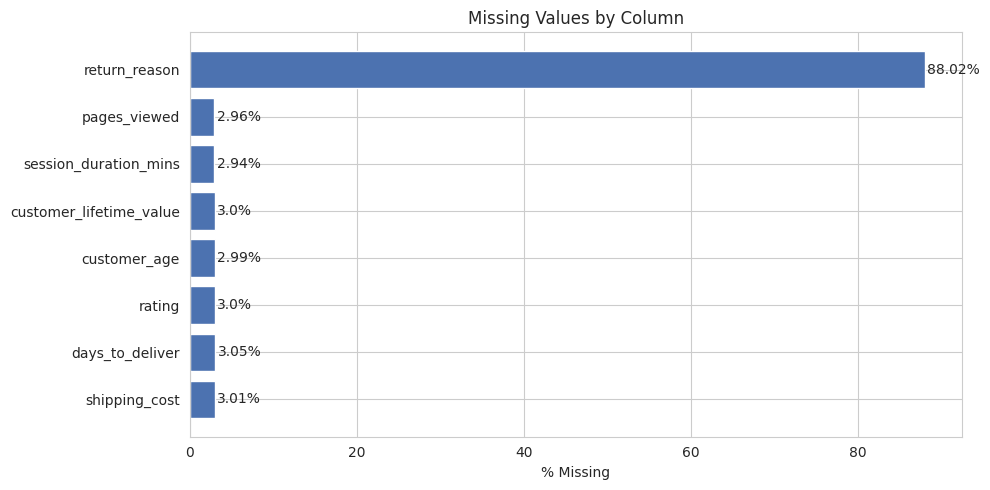

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
cols_with_na = missing_summary[missing_summary['missing_count'] > 0].index
ax.barh(cols_with_na, missing_summary.loc[cols_with_na, 'missing_pct'], color='#4C72B0')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column')
for i, v in enumerate(missing_summary.loc[cols_with_na, 'missing_pct']):
    ax.text(v + 0.3, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate order_id:", df['order_id'].duplicated().sum())


print()
print("return_reason present only when is_returned==1?",
      ((df['return_reason'].notnull()) == (df['is_returned'] == 1)).all())


print("Any row both cancelled AND returned?", ((df['is_cancelled']==1) & (df['is_returned']==1)).any())

Duplicate rows: 0
Duplicate order_id: 0

return_reason present only when is_returned==1? True
Any row both cancelled AND returned? False


In [ ]:

expected_final = df['product_base_price'] * (1 - df['discount_percentage'] / 100)
print("Mean abs error, final_price vs computed:", (expected_final - df['final_price']).abs().mean().round(4))


expected_total = df['final_price'] * df['quantity']
print("Mean abs error, total_amount vs computed:", (expected_total - df['total_amount']).abs().mean())

Mean abs error, final_price vs computed: 0.0019
Mean abs error, total_amount vs computed: 3.21083248877585e-15


---
## Phase 2 — Is Pricing Data Heavily Skewed? (Visualization)

Someone on the team suspects the pricing columns are skewed. Let's check it visually and statistically rather than taking it on faith.

In [7]:
price_cols = ['product_base_price', 'final_price', 'total_amount', 'shipping_cost', 'customer_lifetime_value']

skew_table = pd.DataFrame({
    'mean': df[price_cols].mean(),
    'median': df[price_cols].median(),
    'skewness': df[price_cols].skew(),
    'std': df[price_cols].std()
}).round(2)
skew_table

,mean,median,skewness,std
product_base_price,84.83,60.22,2.01,79.98
final_price,72.44,50.59,2.11,69.90
total_amount,165.61,87.70,4.38,237.41
shipping_cost,34.03,24.89,1.99,39.19
customer_lifetime_value,850.52,604.17,1.99,799.76


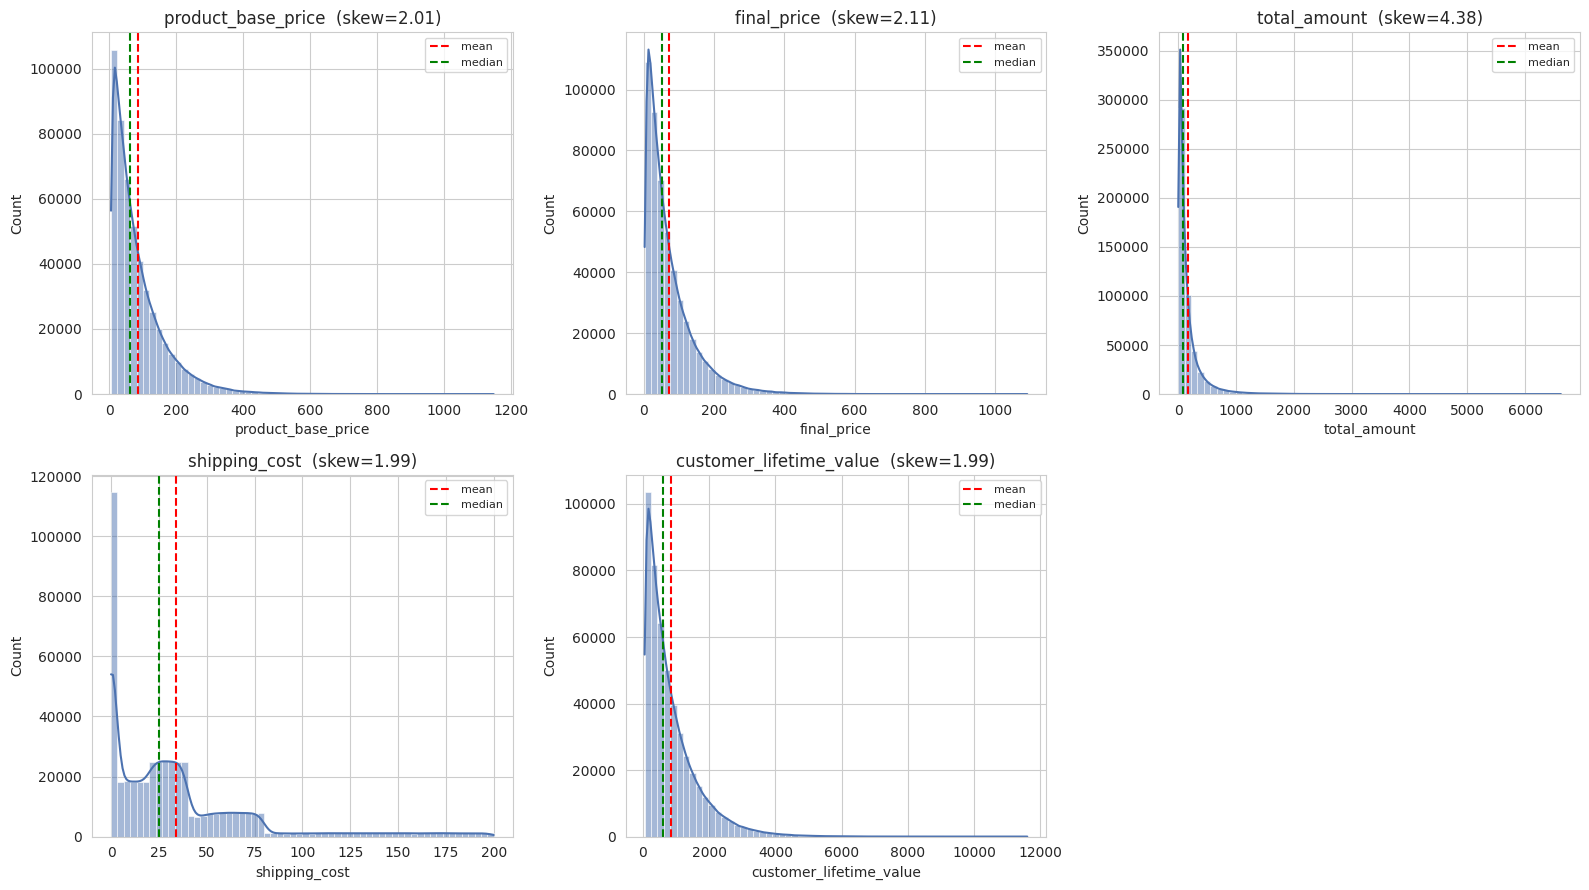

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(price_cols):
    sns.histplot(df[col], bins=60, kde=True, ax=axes[i], color='#4C72B0')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label='median')
    axes[i].set_title(f"{col}  (skew={df[col].skew():.2f})")
    axes[i].legend(fontsize=8)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

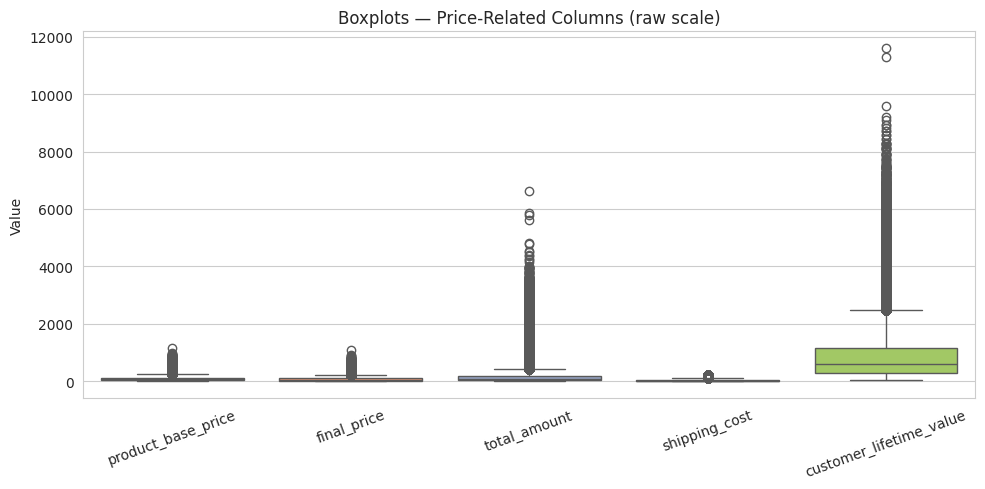

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[price_cols], ax=ax, palette='Set2')
ax.set_title('Boxplots — Price-Related Columns (raw scale)')
ax.set_ylabel('Value')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [10]:
# Quantify outliers via IQR rule
print("Outlier share via 1.5*IQR rule:")
for col in price_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    pct_outliers = (df[col] > upper).mean() * 100
    print(f"  {col:28s}: {pct_outliers:5.2f}% of rows above {upper:,.2f}")

Outlier share via 1.5*IQR rule:
  product_base_price          :  4.84% of rows above 246.89
  final_price                 :  5.08% of rows above 210.12
  total_amount                :  8.60% of rows above 428.61
  shipping_cost               :  6.30% of rows above 103.24
  customer_lifetime_value     :  4.67% of rows above 2,479.81


**Verdict: confirmed — pricing data is heavily right-skewed.**

- All five price/value columns have **skewness > 1.9**, with `total_amount` the worst offender at **~4.4** — driven by `quantity` multiplying an already-skewed `final_price`.
- In every case, **mean > median** by a wide margin (e.g. `total_amount` mean ≈ 166 vs median ≈ 88), the classic right-skew signature.
- 5–9% of rows sit above the IQR outlier fence on each price column — not catastrophic, but enough that **a `StandardScaler` alone would be distorted by the tail**. This is the direct justification for using `RobustScaler` (median/IQR-based) on these columns in Phase 5, instead of mean/std scaling.

---
## Phase 3 — Which Categorical Columns Will Break the ML Pipeline? (EDA)

Not all categoricals are equal. Cardinality, encoding choice, and hidden ordinal structure all matter — get any of these wrong and the pipeline either explodes in dimensionality or silently loses information.

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cardinality = pd.DataFrame({
    'n_unique': [df[c].nunique() for c in cat_cols],
    'dtype': [str(df[c].dtype) for c in cat_cols]
}, index=cat_cols).sort_values('n_unique', ascending=False)
cardinality

,n_unique,dtype
sub_category,45,str
city,15,str
category,10,str
country,8,str
payment_method,6,str
return_reason,5,str
shipping_method,4,str
loyalty_tier,4,str
customer_gender,3,str


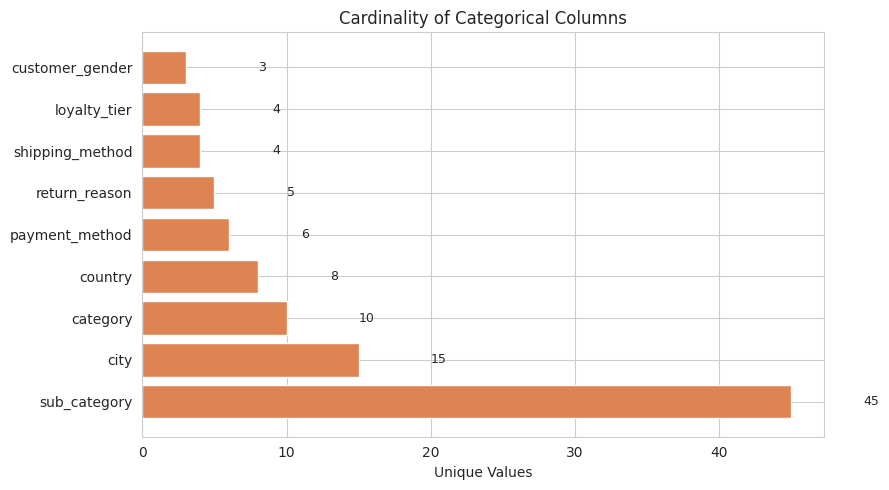

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cardinality.index, cardinality['n_unique'], color='#DD8452')
ax.set_xlabel('Unique Values')
ax.set_title('Cardinality of Categorical Columns')
for i, v in enumerate(cardinality['n_unique']):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# loyalty_tier looks categorical but is secretly ORDINAL — check it's not naturally sorted
print("loyalty_tier raw values:", df['loyalty_tier'].unique())
print()
print("Naive alphabetical sort (WRONG order if label-encoded blindly):",
      sorted(df['loyalty_tier'].unique()))
print()
print("Correct business order: Bronze < Silver < Gold < Platinum")

loyalty_tier raw values: <StringArray>
['Bronze', 'Silver', 'Gold', 'Platinum']
Length: 4, dtype: str

Naive alphabetical sort (WRONG order if label-encoded blindly): ['Bronze', 'Gold', 'Platinum', 'Silver']

Correct business order: Bronze < Silver < Gold < Platinum


In [14]:
# city vs country — is city actually nested inside country, or randomly assigned?
city_country = pd.crosstab(df['country'], df['city'])
print("Cities per country:", df.groupby('country')['city'].nunique().unique())
city_country.iloc[:4, :6]

Cities per country: [15]


city,Bangalore,Berlin,Chennai,Chicago,Delhi,Dubai
country,,,,,,
Australia,1701,1633,1612,1650,1732,1639
Canada,1694,1637,1741,1640,1706,1693
France,2300,2315,2350,2349,2363,2352
Germany,2617,2643,2675,2751,2635,2729


**Findings — three distinct ways categoricals can break a naive pipeline:**

1. **High cardinality (`sub_category`: 45, `city`: 15, `order_date`: 1095 unique values).**
   One-hot encoding `sub_category` and `city` is manageable (~60 extra columns combined), but `order_date` as a raw string/category would be catastrophic — it must be **decomposed into year/month/day-of-week features**, never one-hot encoded as-is.

2. **Hidden ordinal structure in `loyalty_tier`.**
   It has 4 categories — `Bronze, Silver, Gold, Platinum` — that look nominal but are actually a ranked hierarchy. Label-encoding it alphabetically (`Bronze=0, Gold=1, Platinum=2, Silver=3`) would corrupt the natural Bronze→Platinum order. It needs an **explicit `OrdinalEncoder` with `categories=[['Bronze','Silver','Gold','Platinum']]`**, not a generic LabelEncoder or unordered OneHotEncoder.

3. **`city` is not actually nested inside `country`.**
   Every one of the 15 cities appears under *every* one of the 8 countries in roughly equal proportion — e.g. "Bangalore" shows up as often under Australia as under India. This tells us `city` and `country` were generated independently (synthetic data), so **treat them as two unrelated flat categoricals**, not a hierarchical geography — don't try to engineer a "region" feature assuming real-world geographic nesting, it isn't there.

4. (Minor) `return_reason` is categorical but is **target-derived** — it must be dropped before modeling, since it's only populated when `is_returned == 1` and would leak the label directly.

---
## Phase 4 — Why Are Customers Returning Products? (Scenario EDA)

This is the business question. Let's slice returns by category, loyalty tier, payment method, discount level, and reason — the patterns a stakeholder actually cares about.

In [15]:
overall_rate = df['is_returned'].mean()
print(f"Overall return rate: {overall_rate:.2%}")
print(f"Overall cancellation rate: {df['is_cancelled'].mean():.2%}")

Overall return rate: 11.98%
Overall cancellation rate: 6.17%


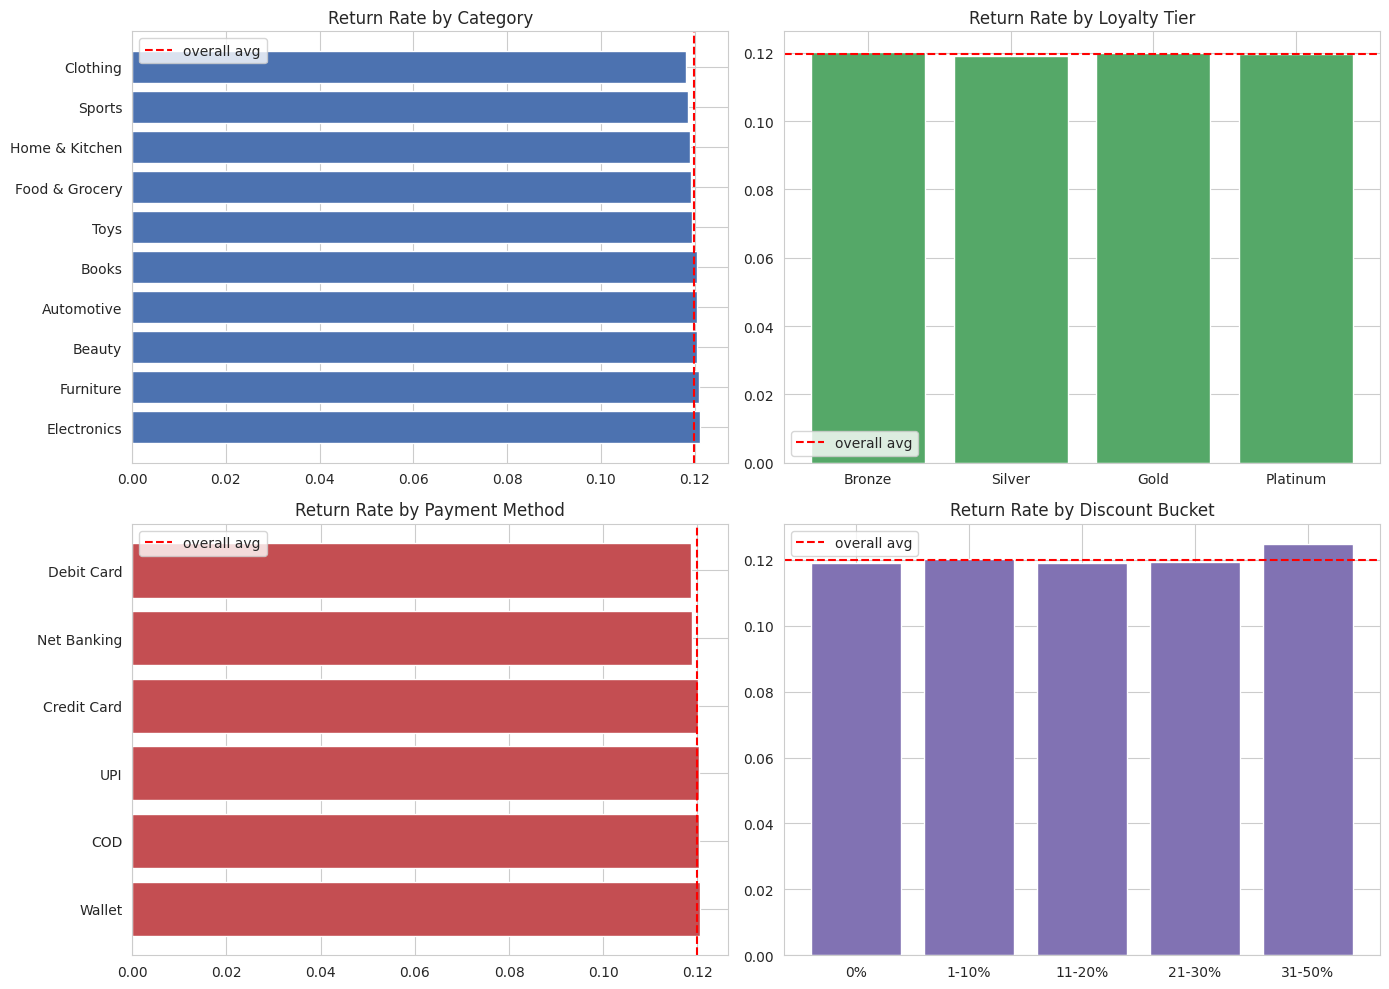

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_rate = df.groupby('category')['is_returned'].mean().sort_values(ascending=False)
axes[0,0].barh(cat_rate.index, cat_rate.values, color='#4C72B0')
axes[0,0].axvline(overall_rate, color='red', linestyle='--', label='overall avg')
axes[0,0].set_title('Return Rate by Category')
axes[0,0].legend()

tier_rate = df.groupby('loyalty_tier')['is_returned'].mean().reindex(['Bronze','Silver','Gold','Platinum'])
axes[0,1].bar(tier_rate.index, tier_rate.values, color='#55A868')
axes[0,1].axhline(overall_rate, color='red', linestyle='--', label='overall avg')
axes[0,1].set_title('Return Rate by Loyalty Tier')
axes[0,1].legend()

pay_rate = df.groupby('payment_method')['is_returned'].mean().sort_values(ascending=False)
axes[1,0].barh(pay_rate.index, pay_rate.values, color='#C44E52')
axes[1,0].axvline(overall_rate, color='red', linestyle='--', label='overall avg')
axes[1,0].set_title('Return Rate by Payment Method')
axes[1,0].legend()

df['discount_bucket'] = pd.cut(df['discount_percentage'], [-1,0,10,20,30,50],
                                 labels=['0%','1-10%','11-20%','21-30%','31-50%'])
disc_rate = df.groupby('discount_bucket')['is_returned'].mean()
axes[1,1].bar(disc_rate.index.astype(str), disc_rate.values, color='#8172B3')
axes[1,1].axhline(overall_rate, color='red', linestyle='--', label='overall avg')
axes[1,1].set_title('Return Rate by Discount Bucket')
axes[1,1].legend()

plt.tight_layout()
plt.show()

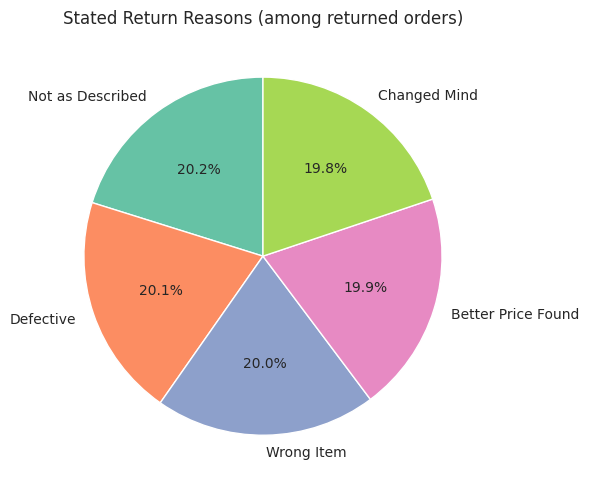

return_reason
Not as Described      12080
Defective             12047
Wrong Item            11962
Better Price Found    11933
Changed Mind          11882
Name: count, dtype: int64

In [17]:
# Stated reasons among orders that WERE returned
reason_counts = df['return_reason'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
ax.pie(reason_counts.values, labels=reason_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette('Set2'), startangle=90)
ax.set_title('Stated Return Reasons (among returned orders)')
plt.tight_layout()
plt.show()
reason_counts

In [18]:
print("Return rate range across category:     {:.3%} to {:.3%}".format(cat_rate.min(), cat_rate.max()))
print("Return rate range across loyalty_tier:  {:.3%} to {:.3%}".format(tier_rate.min(), tier_rate.max()))
print("Return rate range across payment_method: {:.3%} to {:.3%}".format(pay_rate.min(), pay_rate.max()))
print("Return rate range across discount bucket: {:.3%} to {:.3%}".format(disc_rate.min(), disc_rate.max()))

Return rate range across category:     11.819% to 12.114%
Return rate range across loyalty_tier:  11.913% to 12.029%
Return rate range across payment_method: 11.862% to 12.052%
Return rate range across discount bucket: 11.903% to 12.466%


**Findings — and an honest, important one:**

- The **overall return rate is 11.98%**, fairly close to a clean ~12% baseline.
- Cutting return rate by `category`, `loyalty_tier`, `payment_method`, or `discount_bucket` shows **almost no variation** — every group sits within roughly half a percentage point of the 12% overall average. There is no category, tier, or payment method that stands out as meaningfully higher or lower risk.
- Among orders that *were* returned, the five stated reasons (`Not as Described`, `Defective`, `Wrong Item`, `Better Price Found`, `Changed Mind`) are **almost perfectly evenly split (~20% each)** — there's no dominant reason driving returns.
- **Business takeaway:** based on the fields in this dataset, returns appear to be driven by a process that is independent of category, customer tier, payment method, and discount depth. That's a real and useful finding to report upward — it tells the head of analytics that *this dataset, as collected, does not contain the signal needed to predict or explain returns*, and that more granular data (e.g. product quality scores, packaging/courier data, actual product images/descriptions, free-text return comments) would likely be needed to move the needle. We confirm this quantitatively in Phase 6.

---
## Phase 5 — Full ColumnTransformer Pipeline

Different scaling for different distributions (Phase 2), proper ordinal encoding (Phase 3), one-hot for nominal categoricals, and explicit imputation strategies for missing values (Phase 1) — all wired into a single `ColumnTransformer` that's ready to feed a model.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# ---- Feature engineering before the pipeline ----
df_fe = df.copy()
df_fe['order_month'] = df_fe['order_date'].dt.month
df_fe['order_dow']   = df_fe['order_date'].dt.dayofweek
df_fe['order_year']  = df_fe['order_date'].dt.year
df_fe['is_weekend']  = df_fe['order_dow'].isin([5, 6]).astype(int)

df_fe['discount_amount'] = df_fe['product_base_price'] - df_fe['final_price']
df_fe['price_per_unit']  = df_fe['total_amount'] / df_fe['quantity']
df_fe['has_review_history'] = (df_fe['num_reviews'] > 0).astype(int)
df_fe['engagement_score'] = df_fe['pages_viewed'] / (df_fe['session_duration_mins'] + 0.1)

print("New engineered columns:")
print(['order_month','order_dow','order_year','is_weekend',
       'discount_amount','price_per_unit','has_review_history','engagement_score'])

New engineered columns:
['order_month', 'order_dow', 'order_year', 'is_weekend', 'discount_amount', 'price_per_unit', 'has_review_history', 'engagement_score']


In [20]:
# ---- Column groups ----
ordinal_col          = ['loyalty_tier']
ordinal_categories   = [['Bronze', 'Silver', 'Gold', 'Platinum']]

nominal_cols = ['category', 'sub_category', 'shipping_method', 'payment_method',
                'customer_gender', 'country', 'city']

skewed_numeric = ['product_base_price', 'final_price', 'total_amount',
                   'shipping_cost', 'customer_lifetime_value', 'discount_amount']

normal_ish_numeric = ['quantity', 'days_to_deliver', 'rating', 'num_reviews',
                       'customer_age', 'session_duration_mins', 'pages_viewed',
                       'clicks_to_purchase', 'price_per_unit', 'engagement_score',
                       'order_month', 'order_dow', 'order_year']

passthrough_binary = ['is_first_purchase', 'is_weekend', 'has_review_history']

# ---- Build the ColumnTransformer ----
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(categories=ordinal_categories))
    ]), ordinal_col),

    ('nominal', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
    ]), nominal_cols),

    ('skewed_num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', RobustScaler())               # robust to the long tails from Phase 2
    ]), skewed_numeric),

    ('normal_num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), normal_ish_numeric),

    ('binary', 'passthrough', passthrough_binary),
], remainder='drop')

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinal', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [21]:
# ---- Fit/transform on the full feature matrix ----
drop_cols = ['is_returned', 'order_id', 'customer_id', 'product_id',
             'order_date', 'return_reason', 'is_cancelled', 'discount_bucket']

X = df_fe.drop(columns=[c for c in drop_cols if c in df_fe.columns])
y = df_fe['is_returned']

X_transformed = preprocessor.fit_transform(X)
print("Input shape: ", X.shape)
print("Output shape:", X_transformed.shape)
print("Output type: ", type(X_transformed))

Input shape:  (500000, 31)
Output shape: (500000, 114)
Output type:  <class 'scipy.sparse._csr.csr_matrix'>


---
## Phase 6 — Multicollinearity & Predictive Power

Two separate questions here: (a) are features redundant with *each other*, and (b) does anything actually predict `is_returned`?

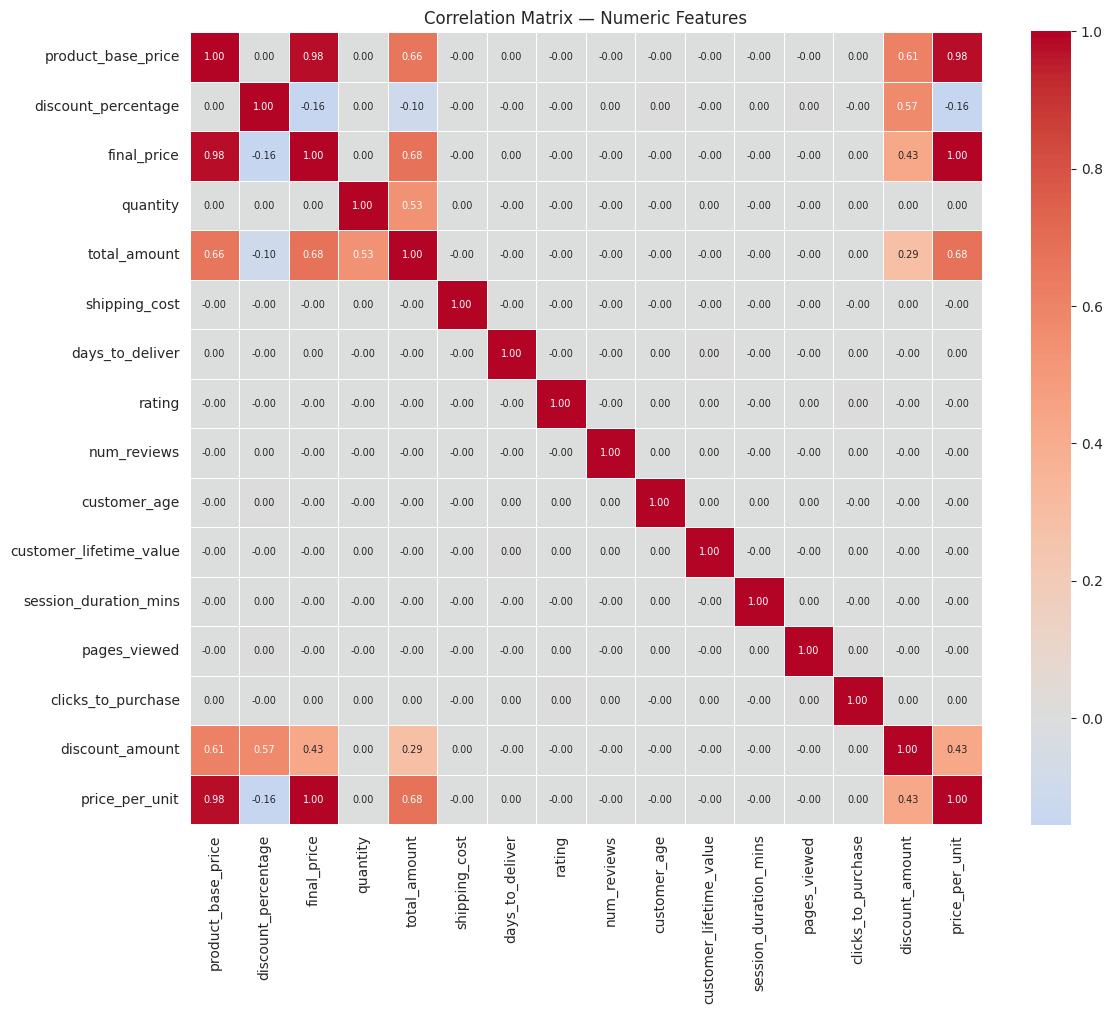

In [22]:
numeric_check_cols = ['product_base_price', 'discount_percentage', 'final_price', 'quantity',
                       'total_amount', 'shipping_cost', 'days_to_deliver', 'rating',
                       'num_reviews', 'customer_age', 'customer_lifetime_value',
                       'session_duration_mins', 'pages_viewed', 'clicks_to_purchase',
                       'discount_amount', 'price_per_unit']

corr_matrix = df_fe[numeric_check_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

In [23]:
# Flag pairs with |r| > 0.6 (multicollinearity candidates)
print("Highly correlated feature pairs (|r| > 0.6):\n")
seen = set()
for i in range(len(numeric_check_cols)):
    for j in range(i+1, len(numeric_check_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            print(f"  {numeric_check_cols[i]:28s} <-> {numeric_check_cols[j]:20s}  r = {r:.3f}")

Highly correlated feature pairs (|r| > 0.6):

  product_base_price           <-> final_price           r = 0.976
  product_base_price           <-> total_amount          r = 0.660
  product_base_price           <-> discount_amount       r = 0.613
  product_base_price           <-> price_per_unit        r = 0.976
  final_price                  <-> total_amount          r = 0.675
  final_price                  <-> price_per_unit        r = 1.000
  total_amount                 <-> price_per_unit        r = 0.675


In [24]:
# Now: does ANYTHING predict is_returned? Numeric correlations first.
target_corr = df_fe[numeric_check_cols + ['is_returned']].corr()['is_returned'].drop('is_returned')
target_corr = target_corr.sort_values(key=abs, ascending=False)
target_corr.to_frame('correlation_with_is_returned')

,correlation_with_is_returned
rating,-0.004459
discount_percentage,0.002670
session_duration_mins,0.002037
price_per_unit,-0.001599
final_price,-0.001599
total_amount,-0.001512
pages_viewed,0.001297
product_base_price,-0.001294
shipping_cost,-0.001265
clicks_to_purchase,-0.000995


In [25]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

cat_assoc_cols = ['category', 'sub_category', 'shipping_method', 'payment_method',
                   'customer_gender', 'country', 'city', 'loyalty_tier']

assoc = pd.Series({c: cramers_v(df_fe[c], df_fe['is_returned']) for c in cat_assoc_cols})
assoc = assoc.sort_values(ascending=False)
assoc.to_frame("Cramer's V vs is_returned")

,Cramer's V vs is_returned
sub_category,0.008928
city,0.004474
country,0.003439
category,0.003028
payment_method,0.002232
loyalty_tier,0.001518
customer_gender,0.001264
shipping_method,0.001195


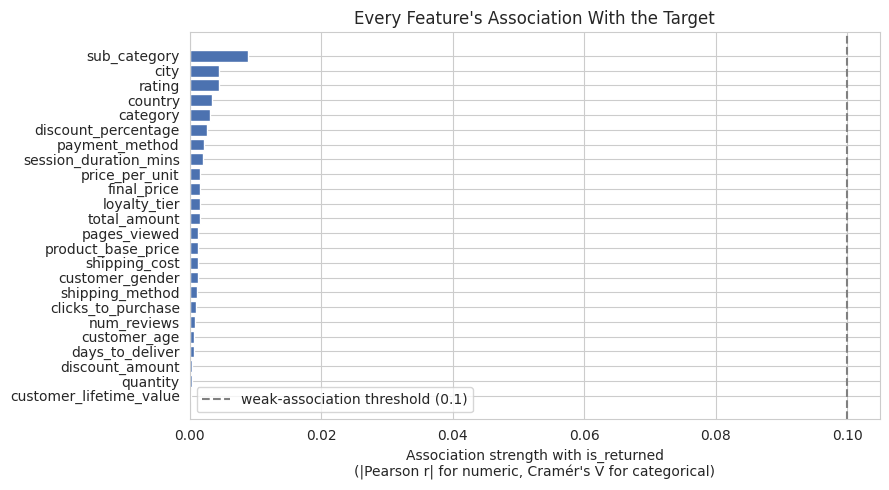

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
combined = pd.concat([target_corr.abs().rename('strength'), assoc.rename('strength')])
combined = combined.sort_values()
colors = ['#C44E52' if v > 0.1 else '#4C72B0' for v in combined.values]
ax.barh(combined.index, combined.values, color=colors)
ax.axvline(0.1, color='gray', linestyle='--', label='weak-association threshold (0.1)')
ax.set_xlabel('Association strength with is_returned\n(|Pearson r| for numeric, Cramér\'s V for categorical)')
ax.set_title('Every Feature\'s Association With the Target')
ax.legend()
plt.tight_layout()
plt.show()